In [85]:
!kaggle datasets download -d mahmoudshaheen1134/oil-sales-dataset

Dataset URL: https://www.kaggle.com/datasets/mahmoudshaheen1134/oil-sales-dataset
License(s): Attribution 4.0 International (CC BY 4.0)




  0%|          | 0.00/50.7k [00:00<?, ?B/s]
100%|██████████| 50.7k/50.7k [00:00<00:00, 232kB/s]
100%|██████████| 50.7k/50.7k [00:00<00:00, 232kB/s]


In [86]:
!kaggle datasets download -d mahmoudshaheen1134/oil-sales-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/mahmoudshaheen1134/oil-sales-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
oil-sales-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [87]:
import pandas as pd

# Load the dataset
df = pd.read_csv("oil_sales_assignment_dataset.csv")

df.head(10)

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
0,AL BAHA,HM No 57296 GS-CENTER-AL BAHA MAIN RD AL BAHA,NOVA FOODS,LARA,COCONUT,0.75L,LARA COCONUT 0.75L TWIN PACK,21-30,2024,12,830.86,30.1,27.6
1,AL KHARJ,HM No 55697 GS-CENTER-AL KHARJ MAIN RD AL K...,PALM & GRAIN GROUP,NAJMA,CANOLA,0.5L,NAJMA CANOLA 0.5L TWIN PACK,41-50,2024,10,373.10,9.1,41.0
2,RIYADH,HM No 86781 GS-CENTER-RIYADH MAIN RD RIYADH,AL HILAL INDUSTRIES,BAYTNA,SUNFLOWER,0.75L,BAYTNA SUNFLOWER 0.75L ECO,101+,2023,1,171.70,1.7,101.0
3,DAMMAM,HM No 95753 GS-CENTER-DAMMAM MAIN RD DAMMAM,PALM & GRAIN GROUP,NOUR,CORN,0.6L,NOUR CORN 0.6L TWIN PACK,61-70,2022,2,1226.10,20.1,61.0
4,JAZAN,HM No 56338 GS-CENTER-JAZAN MAIN RD JAZAN,DESERT SUN CO,NOUR,VEGETABLE,1L,NOUR VEGETABLE 1L,81-90,2024,2,996.30,12.3,81.0
5,JAZAN,HM No 55164 GS-CENTER-JAZAN MAIN RD JAZAN,NAJDI CONSUMER,RIMAL,CORN,4L,RIMAL CORN 4L TWIN PACK,21-30,2022,11,1050.00,35.0,30.0
6,TAIF,HM No 68965 GS-CENTER-TAIF MAIN RD TAIF,ARABIAN HARVEST CO,HILAL,CANOLA,1.8L,HILAL CANOLA 1.8L PLUS,81-90,2024,6,194.40,2.4,81.0
7,DAMMAM,HM No 74260 GS-CENTER-DAMMAM MAIN RD DAMMAM,DESERT SUN CO,HILAL,CORN,9L,HILAL CORN 9L FAMILY PACK,21-30,2024,11,60.00,2.0,30.0
8,DAMMAM,HM No 85005 GS-CENTER-DAMMAM MAIN RD DAMMAM,AL HILAL INDUSTRIES,GULF GOLD,SUNFLOWER,1.8L,GULF GOLD SUNFLOWER 1.8L PLUS,91-100,2022,11,673.40,7.4,91.0
9,HAIL,HM No 53665 GS-CENTER-HAIL MAIN RD HAIL,AL HILAL INDUSTRIES,NAJMA,CORN,1.8L,NAJMA CORN 1.8L PLUS,21-30,2022,10,102.00,3.4,30.0


Hypothesis

1. Most selling price_braket is 21-30 which is min average_price
2. Sunflore oil has high price_braket and it has high average_price
3. High volume selling oils are coconut and corn
4. Min size of oil pack is .6-1

In [88]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city           2000 non-null   object 
 1   store_name     2000 non-null   object 
 2   manufacturer   2000 non-null   object 
 3   brand          2000 non-null   object 
 4   class          2000 non-null   object 
 5   size           2000 non-null   object 
 6   sku            2000 non-null   object 
 7   price_bracket  2000 non-null   object 
 8   year           2000 non-null   int64  
 9   month          2000 non-null   int64  
 10  value_sales    2000 non-null   float64
 11  volume_sales   2000 non-null   float64
 12  average_price  2000 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 203.3+ KB


,year,month,value_sales,volume_sales,average_price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2022.990500,6.639500,614.839355,9.972100,60.990230
std,0.820211,3.468942,750.794991,9.862369,29.457029
min,2022.000000,1.000000,6.960000,0.500000,11.000000
25%,2022.000000,4.000000,132.000000,2.900000,37.337500
50%,2023.000000,7.000000,368.320000,7.000000,61.000000
75%,2024.000000,10.000000,794.100000,13.800000,81.000000
max,2024.000000,12.000000,6253.200000,81.700000,140.000000


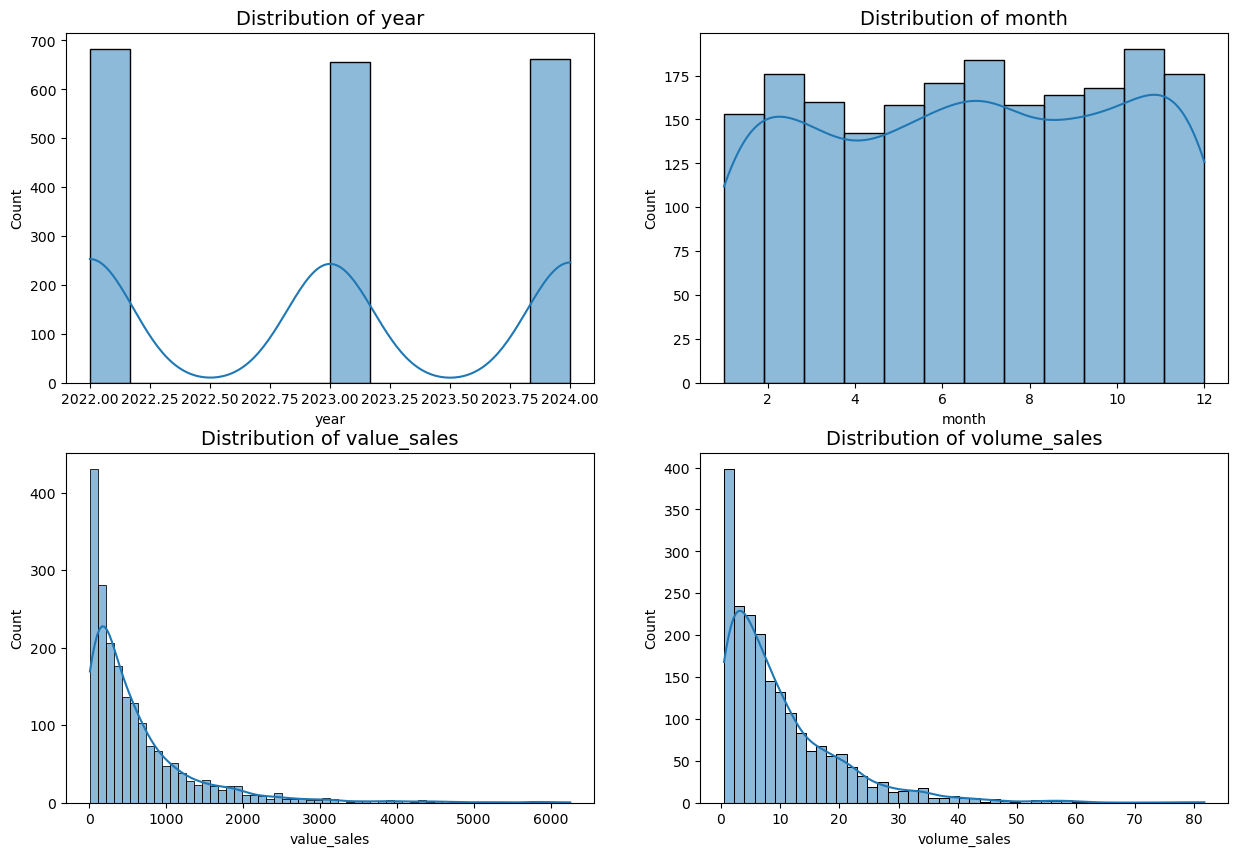

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

fig,axes = plt.subplots(2,2,figsize=(15,10))

for ax,col in zip(axes.flatten(),df.select_dtypes(include='number').columns):
    sns.histplot(df[col],ax=ax,kde=True)
    ax.set_title(f'Distribution of {col}',fontsize=14)

In [90]:
#Skewness in the value_sales and volume_sales columns

print("Skewness of value_sales:", df['value_sales'].skew())
print("Skewness of volume_sales:", df['volume_sales'].skew())

Skewness of value_sales: 2.78447987641009
Skewness of volume_sales: 1.9924262671929096


array([[<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'month'}>],
       [<Axes: title={'center': 'value_sales'}>,
        <Axes: title={'center': 'volume_sales'}>],
       [<Axes: title={'center': 'average_price'}>, <Axes: >]],
      dtype=object)

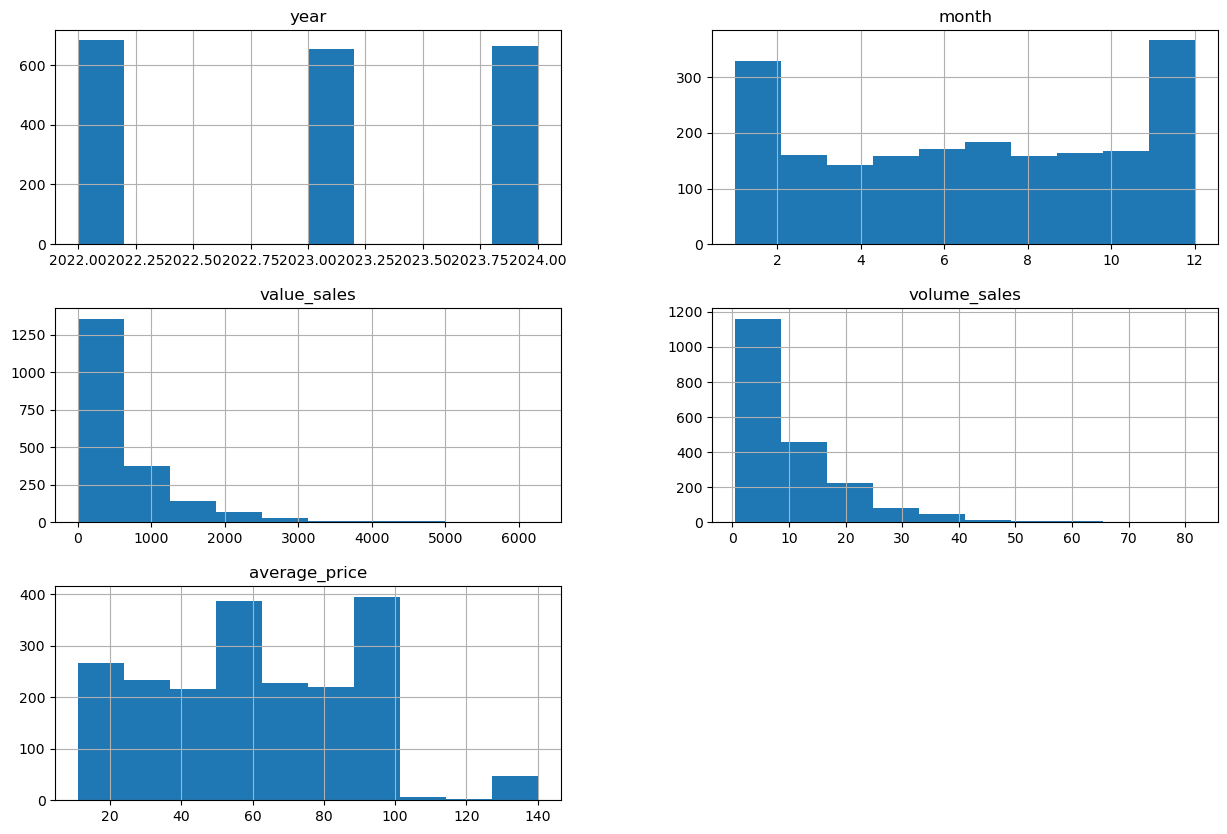

In [91]:
df.hist(figsize=(15,10))

<Axes: >

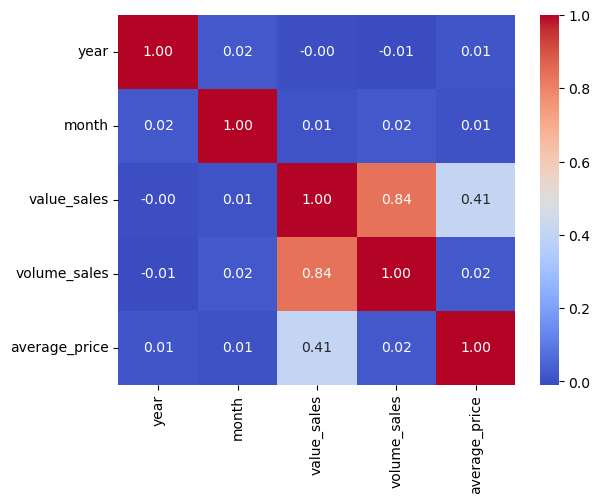

In [92]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")

In [93]:
df.isnull().sum()
df.duplicated().sum()

df

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
0,AL BAHA,HM No 57296 GS-CENTER-AL BAHA MAIN RD AL BAHA,NOVA FOODS,LARA,COCONUT,0.75L,LARA COCONUT 0.75L TWIN PACK,21-30,2024,12,830.86,30.1,27.6
1,AL KHARJ,HM No 55697 GS-CENTER-AL KHARJ MAIN RD AL K...,PALM & GRAIN GROUP,NAJMA,CANOLA,0.5L,NAJMA CANOLA 0.5L TWIN PACK,41-50,2024,10,373.10,9.1,41.0
2,RIYADH,HM No 86781 GS-CENTER-RIYADH MAIN RD RIYADH,AL HILAL INDUSTRIES,BAYTNA,SUNFLOWER,0.75L,BAYTNA SUNFLOWER 0.75L ECO,101+,2023,1,171.70,1.7,101.0
3,DAMMAM,HM No 95753 GS-CENTER-DAMMAM MAIN RD DAMMAM,PALM & GRAIN GROUP,NOUR,CORN,0.6L,NOUR CORN 0.6L TWIN PACK,61-70,2022,2,1226.10,20.1,61.0
4,JAZAN,HM No 56338 GS-CENTER-JAZAN MAIN RD JAZAN,DESERT SUN CO,NOUR,VEGETABLE,1L,NOUR VEGETABLE 1L,81-90,2024,2,996.30,12.3,81.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,TABUK,HM No 99317 GS-CENTER-TABUK MAIN RD TABUK,NAJDI CONSUMER,LARA,COCONUT,0.5L,LARA COCONUT 0.5L PREMIUM,31-40,2024,11,74.40,2.4,31.0
1996,AL AHSA,HM No 85390 GS-CENTER-AL AHSA MAIN RD AL AHSA,BLUE OASIS CO,LARA,SUNFLOWER,3L,LARA SUNFLOWER 3L,31-40,2022,5,20.00,0.5,40.0
1997,AL KHARJ,HM No 90740 GS-CENTER-AL KHARJ MAIN RD AL K...,NOVA FOODS,NOUR,SUNFLOWER,2.9L,NOUR SUNFLOWER 2.9L,91-100,2023,8,527.80,5.8,91.0
1998,RIYADH,HM No 52893 GS-CENTER-RIYADH MAIN RD RIYADH,NOVA FOODS,NAJMA,CORN,0.75L,NAJMA CORN 0.75L ECO,61-70,2024,6,305.00,5.0,61.0


In [94]:
df['value_per_unit'] = df['value_sales'] / df['volume_sales']

In [95]:
Q1 = df['value_sales'].quantile(.25)
Q3 = df['value_sales'].quantile(.75)

IQR = Q3-Q1

lower_band = Q1-IQR*1.5
upper_band = Q3+IQR*1.5

df['value_sales'] = df['value_sales'].clip(lower_band,upper_band)

<Axes: >

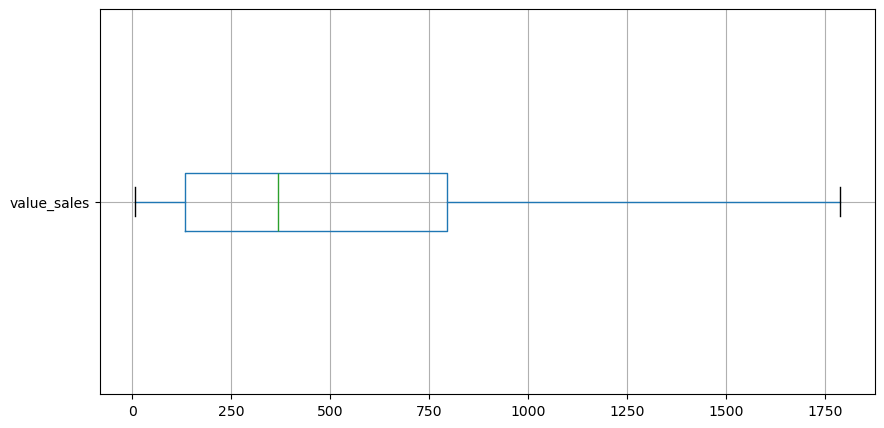

In [96]:
df.boxplot(column='value_sales', vert=False, figsize=(10,5))

In [97]:
Q1 = df['volume_sales'].quantile(.25)
Q3 = df['volume_sales'].quantile(.75)

IQR = Q3-Q1

lower_band = Q1-IQR*1.5
upper_band = Q3+IQR*1.5

df['volume_sales'] = df['volume_sales'].clip(lower_band,upper_band)

<Axes: >

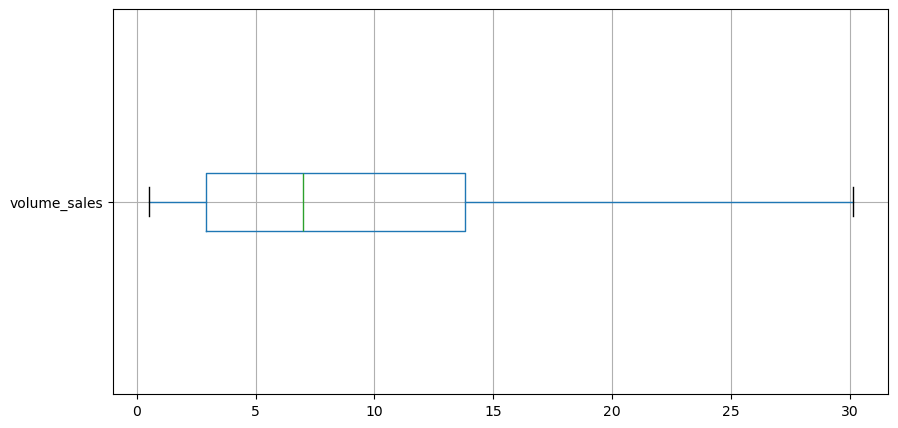

In [98]:
df.boxplot(column='volume_sales',vert=False,figsize=(10,5))

In [100]:
Q1 = df['value_sales'].quantile(.25)
Q3 = df['value_sales'].quantile(.75)

IQR = Q3-Q1

lower_band = Q1-IQR*1.5
upper_band = Q3+IQR*1.5

df['value_sales'] = df['value_sales'].clip(lower_band,upper_band)

In [103]:
df.columns

Index(['city', 'store_name', 'manufacturer', 'brand', 'class', 'size', 'sku',
       'price_bracket', 'year', 'month', 'value_sales', 'volume_sales',
       'average_price', 'value_per_unit'],
      dtype='object')

In [ ]:
df['size'] = df['size'].apply(lambda x: x.replace("L","").strip()).astype(float)*1000

In [147]:
X = X.drop(columns=['city','store_name','manufacturer','brand'])

In [156]:
X = df.drop(['value_per_unit','city','store_name','manufacturer','brand','sku'], axis=1)
y = df['value_per_unit']

cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

In [149]:
print(cat_cols[:])
print(num_cols)

Index(['city', 'store_name', 'manufacturer', 'brand', 'class', 'sku',
       'price_bracket'],
      dtype='object')
Index(['size', 'year', 'month', 'value_sales', 'volume_sales',
       'average_price'],
      dtype='object')


In [158]:
X = pd.get_dummies(X,columns=['class', 'price_bracket'],drop_first=True)

In [160]:
X.shape, X.columns

((2000, 19),
 Index(['size', 'year', 'month', 'value_sales', 'volume_sales', 'average_price',
        'class_COCONUT', 'class_CORN', 'class_SUNFLOWER', 'class_VEGETABLE',
        'price_bracket_11-20$', 'price_bracket_21-30', 'price_bracket_31-40',
        'price_bracket_41-50', 'price_bracket_51-60', 'price_bracket_61-70',
        'price_bracket_71-80', 'price_bracket_81-90', 'price_bracket_91-100'],
       dtype='object'))

In [162]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1600, 19)
(400, 19)
(1600,)
(400,)


In [164]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [168]:
model = LinearRegression()
model = model.fit(X_train_scale,y_train)
y_pred = model.predict(X_test_scale)

In [169]:
result = pd.DataFrame({'Actual':y_test,'Prediected':y_pred})
result.head(10)

,Actual,Prediected
1860,101.0,101.000012
353,40.0,39.999930
1333,90.0,89.999905
905,30.0,30.000134
1289,81.0,81.000043
1273,60.0,60.000145
938,91.0,90.999982
1731,30.0,30.000160
65,81.0,81.000031
1323,60.0,60.000160


In [170]:
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.0001968304123869302
MSE : 4.774374076777659e-07
RMSE: 0.0006909684563551117
R²  : 0.9999999993514761


In [172]:
from sklearn.model_selection import cross_val_score

model = LinearRegression()
scores = cross_val_score(model,X,y,cv=5,scoring='r2')
print(scores)
print(scores.mean())

[1. 1. 1. 1. 1.]
0.9999999994616054
